# IS477 - Public health indicators and gun violence victimization across Chicago community areas

- Group Member: Vivian Lin and Yoyo Lin

## Introduction

### Motivation

One of our teammates previously lived in Chicago for several months but has not explored many of its neighborhoods due to concerns about personal safety, which limited her ability to see the city beyond familiar areas. This limited exposure sparked our curiosity about how different community areas experience violence differently. In addition, both of us are interested in leveraging societal and medical statistics to better understand these disparities and to explore broader societal issues related to public health, safety, and community well-being.

Building on this curiosity, our project examines how community-level public health and socioeconomic conditions relate to gun violence outcomes across Chicago community areas. We will integrate a community area dataset of selected public health indicators with victim level records of homicide and nonfatal shooting victimizations. Our goal is to identify patterns and associations supported by the data, while communicating results responsibly. We will avoid causal claims and refrain from language that stigmatizes communities.

### Research Questions

#### Primary
1. Which community level public health and socioeconomic indicators are most strongly associated with higher gun violence victimization burden across Chicago community areas?

#### Secondary
1. What is the homicide victim count by community area for each year?
2. What is the total gun violence victim count by community area for each year?
3. What are the aggregated demographic summaries by community area for each year, reported only at safe aggregation levels?


### Imports and Helper Functions

This section imports the libraries used throughout the notebook and defines a few helper functions for standardizing column names and community-area text before the merge.


In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import geodatasets
from shapely.geometry import Point
import seaborn as sns
import scipy.stats as stats
import numpy as np
import geopandas as gpd

# Helper functions.
# Convert the column names into same format.
def standardize_name(name):
    if pd.isna(name):
        return name
    return str(name).strip().lower().replace(" ", "_") 

# Convert the data in to uppercase.
def to_uppercase(data):
    if pd.isna(data):
        return data
    return str(data).upper()

# Create age groups.
def age_group(age):
    if pd.isna(age): return "Unknown"
    if age in ["0-19", "20-29"]: return "0-29"
    if age in ["30-39", "40-49"]: return "30-49"
    if age in ["50-59", "60-69"]: return "50-69"
    return "70+"

### Data Processing

In this section, we load the public health and violence datasets, standardize their community-area fields, merge them together, and keep the shared `2005-2011` time period used for the project analysis.


In [165]:
# Load the datasets and check for NaN values.
df_vio = pd.read_csv("Violence_Reduction_-_Victims_of_Homicides_and_Non-Fatal_Shootings_20260302.csv")
df_stat = pd.read_csv("Public_Health_Statistics_-_Selected_public_health_indicators_by_Chicago_community_area_-_Historical_20260302.csv")

# Check if there is any data that doesn't have a value.
df_vio["COMMUNITY_AREA"].isna().sum()
df_stat["Community Area Name"].isna().sum()

# Drop rows where "COMMUNITY_AREA" column has nan vaule.
df_vio = df_vio.dropna(subset=["COMMUNITY_AREA"])

# Step 1: Ensure the column namse and the combine keys are having the same format.
df_vio.columns = [standardize_name(col) for col in df_vio.columns]
df_stat.columns = [standardize_name(col) for col in df_stat.columns]

# Step 2: Ensure the combine keys are having the same format.
# Check the information within the keys.
df_vio["community_area"].unique()
df_stat["community_area_name"].unique()

# Mapping for known mismatches, like O'Hare.
name_mapping = {"OHARE": "O'HARE", "Montclaire": "Montclare"}
df_vio["community_area"] = df_vio["community_area"].replace(name_mapping)
df_stat["community_area_name"] = df_stat["community_area_name"].replace(name_mapping)

df_vio["community_area"] = df_vio["community_area"].apply(to_uppercase)
df_stat["community_area_name"] = df_stat["community_area_name"].apply(to_uppercase)

# Step 3: Create crosswalk from number using df_stat as source of truth.
crosswalk = (df_stat[["community_area", "community_area_name"]].drop_duplicates()
             .set_index("community_area_name")["community_area"].to_dict())

# Step 4: Convert to datetime.
df_vio["date"] = pd.to_datetime(df_vio["date"], format="%m/%d/%Y %I:%M:%S %p")
df_vio["date_only"] = df_vio["date"].dt.date
df_vio["year"] = df_vio["date"].dt.year
#df_vio["time"] = df_vio["date"].dt.time

# Step 5: Combine the two datasets with keys.
df_merged = pd.merge(df_vio, df_stat, left_on="community_area", right_on="community_area_name")

# Step 6: Validate the join.
vio_area = df_vio["community_area"].unique()
stat_area = df_stat["community_area_name"].unique()
merged_area = df_merged["community_area_x"].unique()

# Convert arrays to sets.
vio_set = set(vio_area)
stat_set = set(stat_area)
merged_set = set(merged_area)

# Check differences.
print("In vio_area but not in stat_area:", vio_set - stat_set)
print("In stat_area but not in vio_area:", stat_set - vio_set)

print("In vio_area but not in merged_area:", vio_set - merged_set)
print("In merged_area but not in vio_area:", merged_set - vio_set)

print("In stat_area but not in merged_area:", stat_set - merged_set)
print("In merged_area but not in stat_area:", merged_set - stat_set)

# Step 7: Save the merged file for futher use.
df_merged.to_csv("merged.csv")


# Output the results.
#df_vio["community_area"].head(5)
#df_vio["community_area"].value_counts()
#f_vio.shape
#df_vio.dtypes
#df_stat["community_area_name"].head(5)
#df_stat["community_area_name"].value_counts()
#df_stat.dtypes
#df_merged.head(5)
# df_merged.shape


In vio_area but not in stat_area: set()
In stat_area but not in vio_area: set()
In vio_area but not in merged_area: set()
In merged_area but not in vio_area: set()
In stat_area but not in merged_area: set()
In merged_area but not in stat_area: set()


### Analysis and Corresponding Plots

#### Overall Crime Incident Changes and Crime Maps from 2005 to 2011

The first set of visualizations gives a broad overview of how violence incidents change over time and where incidents are located across Chicago.


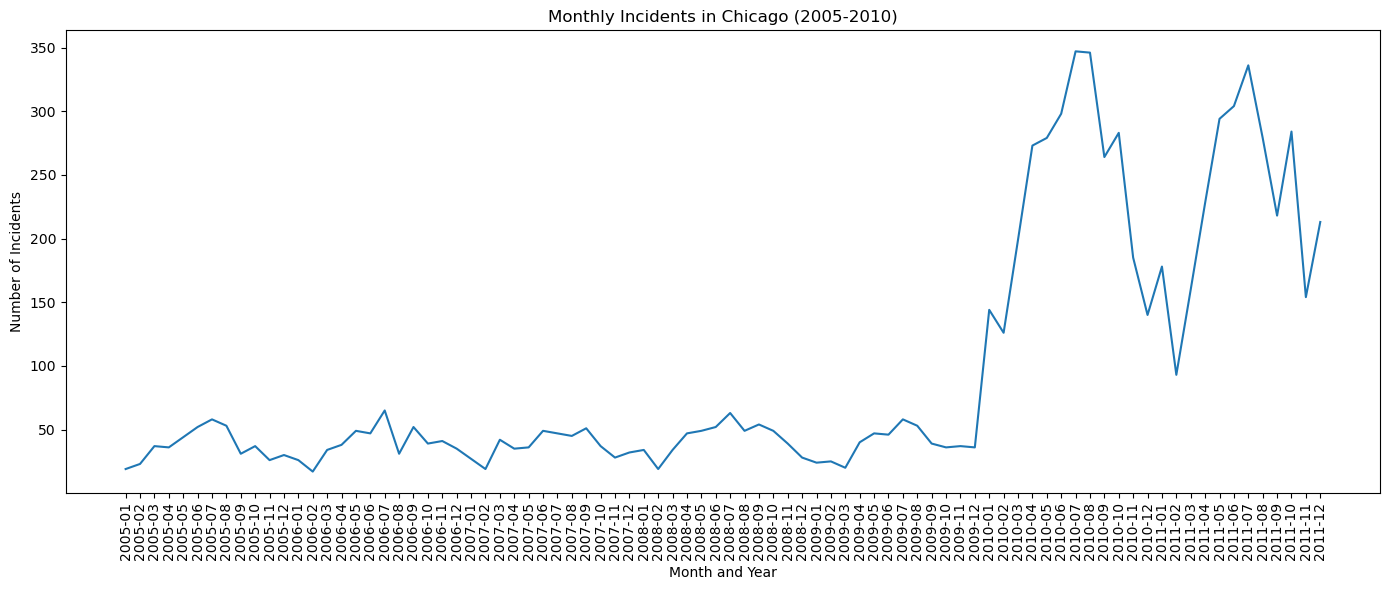

In [166]:
#Filter the time period where both datasets overlap (2005 to 2011).
df_merged = df_merged[(df_merged["year"] >= 2005) & (df_merged["year"] <= 2011)]

# Overall violence incidents change by year and month.
df_merged["month_year"] = df_merged["date"].dt.to_period("M")

trend_mon = df_merged.groupby("month_year").size().reset_index(name="incidents")
trend_mon["month_year"] = trend_mon["month_year"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_mon, x="month_year", y="incidents")
plt.xticks(rotation=90)
plt.title("Monthly Incidents in Chicago (2005-2010)")
plt.xlabel("Month and Year")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()


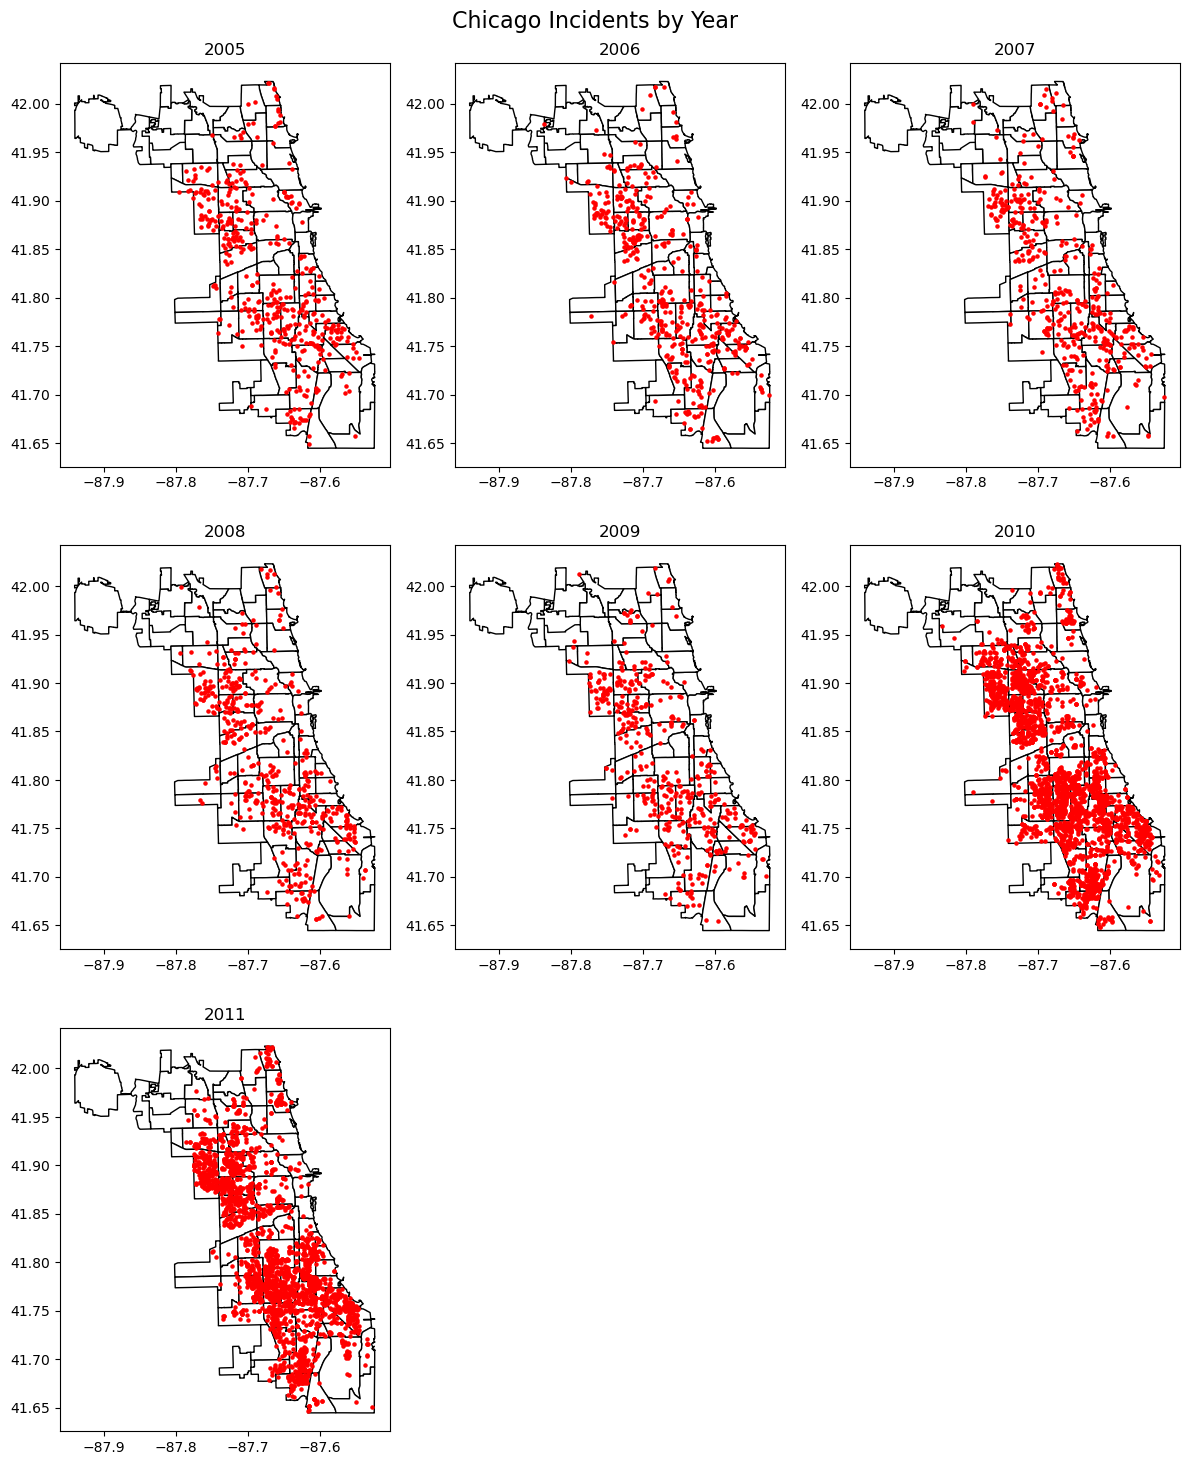

In [167]:
# Method comes from: https://towardsdatascience.com/plotting-maps-with-geopandas-428c97295a73/
# Chicago polygons.
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

# Convert data to a GeoDataFrame.
geometry = [Point(xy) for xy in zip(df_merged["longitude"], df_merged["latitude"])]
geo_df = gpd.GeoDataFrame(df_merged, geometry=geometry)
geo_df.set_crs(epsg=4326, inplace=True)
geo_df = geo_df.to_crs(chicago.crs)

# fig, ax = plt.subplots(figsize=(10, 10))

# # Base map.
# chicago.plot(ax=ax, color="white", edgecolor="black")

# # Data.
# geo_df.plot(ax=ax, color="red", markersize=5)

# plt.title("My Data on Chicago Map")
# plt.show()

# # Assign each point to a community area.
# joined = gpd.sjoin(geo_df, chicago, how="left", predicate='within')

# # Count points per community area.
# counts = joined.groupby("community")[['geometry']].count().rename(columns={'geometry': 'point_count'})

# # Merge counts back to chicago polygons.
# chicago_counts = chicago.merge(counts, left_on="community", right_index=True, how="left")
# chicago_counts['point_count'] = chicago_counts['point_count'].fillna(0)  # fill NaN with 0

# # Plot choropleth.
# fig, ax = plt.subplots(figsize=(10, 10))
# chicago_counts.plot(column='point_count', ax=ax, cmap='OrRd', edgecolor='black', legend=True)
# plt.title("Number of Points per Community Area in Chicago")
# plt.show()

years = sorted(geo_df["year"].dropna().unique())

# Set up the rows and columns for the subplot.
n_cols = 3
n_rows = int(np.ceil(len(years) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter data for that year.
    subset = geo_df[geo_df["year"] == year]
    
    # Base map.
    chicago.plot(ax=ax, color="white", edgecolor="black")
    
    # Points.
    subset.plot(ax=ax, color="red", markersize=5)
    
    ax.set_title(f"{year}")

# Remove empty subplots.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Chicago Incidents by Year", fontsize=16)
plt.tight_layout()
plt.show()

#### Violence Victim Demography

These plots summarize the demographic composition of victims in the merged dataset using age, sex, and race.


/var/folders/sl/nkyrzpxx0dl5krcsxt3c69cc0000gn/T/ipykernel_18736/1727898267.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merged, x="age", order=AGES, palette=colors)


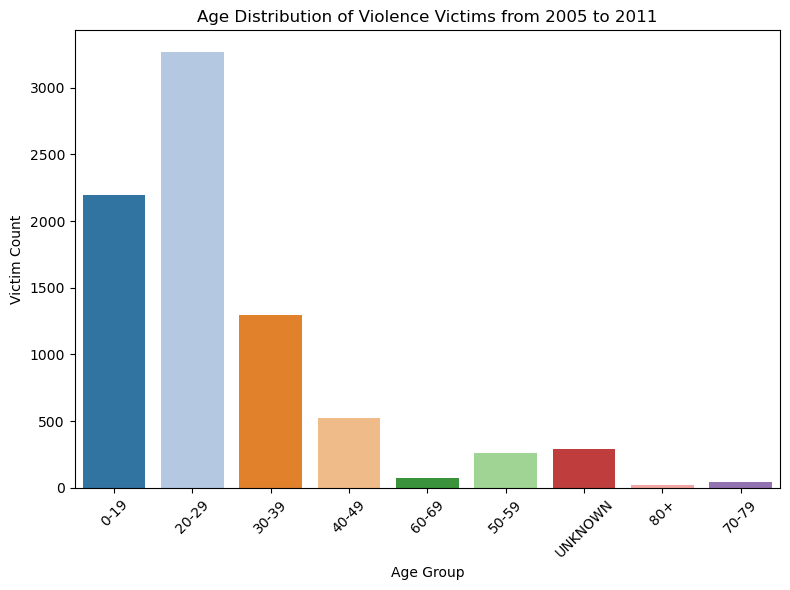

In [168]:
# Age group distribution.
AGES = df_merged["age"].unique()

# Define a list of colors.
colors = sns.color_palette("tab20", len(AGES)) 

# Bar chart.
plt.figure(figsize=(8, 6))
sns.countplot(data=df_merged, x="age", order=AGES, palette=colors)
plt.title("Age Distribution of Violence Victims from 2005 to 2011")
plt.xlabel("Age Group")
plt.ylabel("Victim Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


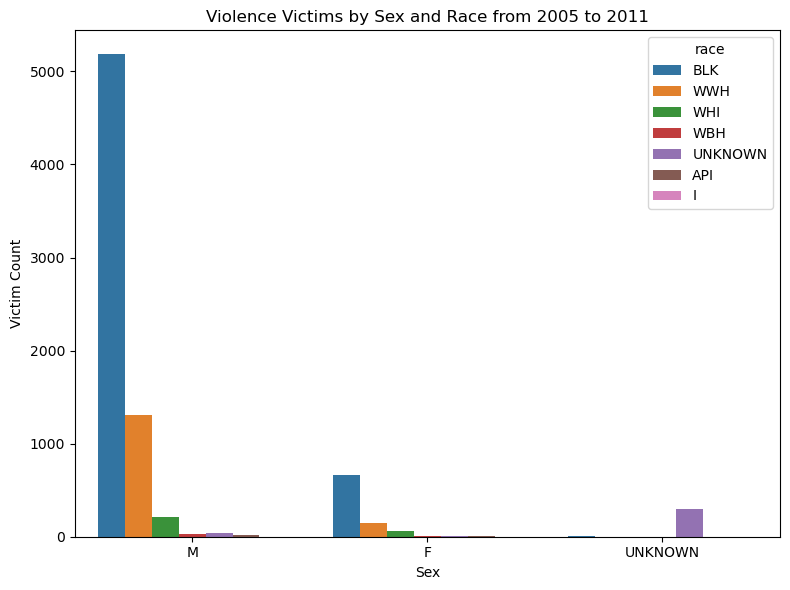

In [169]:
# By sex and race.
plt.figure(figsize=(8, 6))
sns.countplot(data=df_merged, x="sex", hue="race")
plt.title("Violence Victims by Sex and Race from 2005 to 2011")
plt.xlabel("Sex")
plt.ylabel("Victim Count")
plt.tight_layout()
plt.show()


#### Temporal Patterns for the Violence Incidents

These heatmaps summarize when incidents occur during the week, across the day, and across the calendar year.


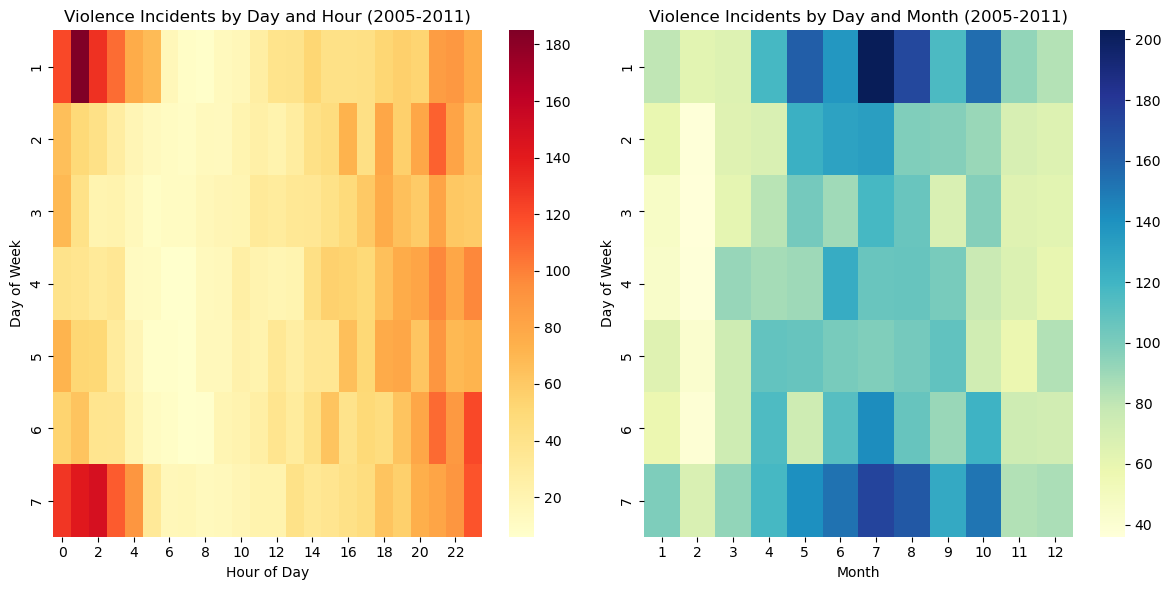

In [170]:
# Set up the subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Day of week by hour of day.
sns.heatmap(df_merged.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0),
            cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Violence Incidents by Day and Hour (2005-2011)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Day of Week')

# Day of week by month.
sns.heatmap(df_merged.pivot_table(index='day_of_week', columns='month', aggfunc='size', fill_value=0),
            cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Violence Incidents by Day and Month (2005-2011)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

#### Research Questions

##### Q1: Which community level public health and socioeconomic indicators are most strongly associated with higher gun violence victimization burden across Chicago community areas?

The sections below summarize outcomes tied to the project questions before moving to an additional indicator-focused analysis at the end of the notebook.


In [171]:
# This question is explored in the later indicator-analysis section added at the end of the notebook.


##### Q2: What is the homicide victim count by community area for each year?

This section summarizes yearly homicide victim counts and compares community areas with the highest burden.


In [172]:
# Filter the incidents that are related to homicide.
df_hom = df_merged[df_merged["victimization_primary"] == "HOMICIDE"]

# Count the incidents by area and year.
homicide_by_area_year = (df_hom.groupby(["community_area_name", "year"]).size()
                         .reset_index(name="homicide_victim_count")
                         .sort_values(["community_area_name", "year"]))

# Output the result.
homicide_by_area_year.head(5)

,community_area_name,year,homicide_victim_count
0,ALBANY PARK,2005,4
1,ALBANY PARK,2007,3
2,ALBANY PARK,2008,3
3,ALBANY PARK,2009,8
4,ALBANY PARK,2010,1


In [173]:
# Homicide rate by community area.
homicide_rate = df_hom.groupby("community_area_name").size() / df_merged.groupby("community_area_name").size() * 100

# Output the result.
homicide_rate.head(10)

community_area_name
ALBANY PARK        52.500000
ARCHER HEIGHTS     76.923077
ARMOUR SQUARE     100.000000
ASHBURN            22.222222
AUBURN GRESHAM     38.187702
AUSTIN             42.307692
AVALON PARK        40.000000
AVONDALE           36.206897
BELMONT CRAGIN     28.688525
BEVERLY            50.000000
dtype: float64

In [174]:
# Unify the color for community names for future plotting.
# Get unique community names.
all_communities = df_merged["community_area_name"].unique()

# Create a color palette.
palette = sns.color_palette("tab10", n_colors=len(all_communities))

# Map each community to a color.
color_dict = dict(zip(all_communities, palette))

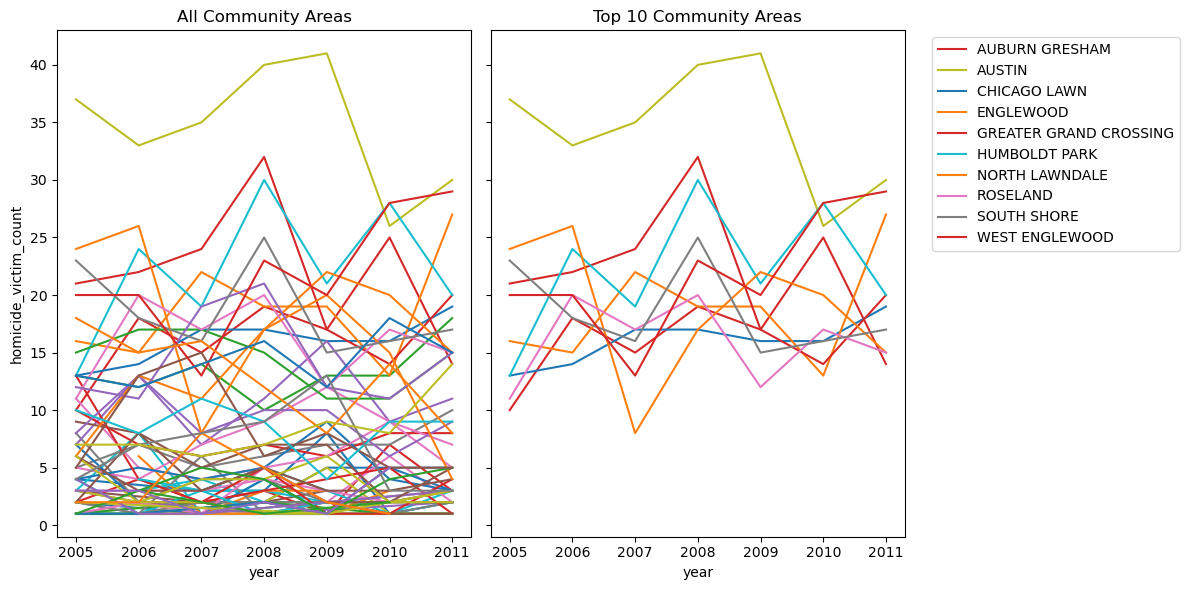

In [175]:
# Find the top 10 areas by total homicides.
top_areas = (homicide_by_area_year.groupby("community_area_name")["homicide_victim_count"]
               .sum().sort_values(ascending=False).head(10))

top_areas_idx = top_areas.index

top10_data = homicide_by_area_year[homicide_by_area_year["community_area_name"].isin(top_areas_idx)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# All areas.
sns.lineplot(
    data=homicide_by_area_year,
    x="year",
    y="homicide_victim_count",
    hue="community_area_name",
    palette=color_dict,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("All Community Areas")

# Top 10 areas.
sns.lineplot(
    data=top10_data,
    x="year",
    y="homicide_victim_count",
    hue="community_area_name",
    palette=color_dict,
    ax=axes[1]
)

axes[1].set_title("Top 10 Community Areas")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

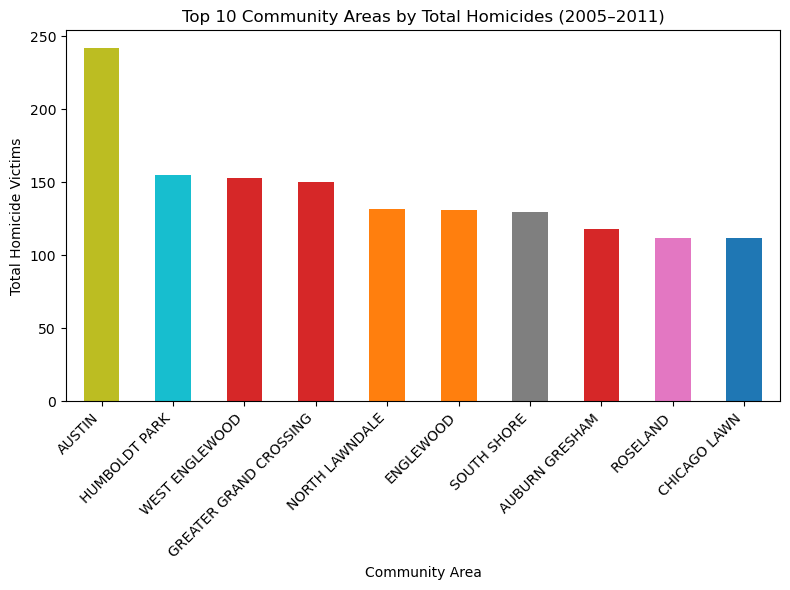

In [176]:
# Extract colors in the same order as top_areas.
bar_colors = [color_dict[area] for area in top_areas.index]

top_areas.plot(
    kind="bar",
    figsize=(8, 6),
    color=bar_colors
)

plt.title("Top 10 Community Areas by Total Homicides (2005–2011)")
plt.xlabel("Community Area")
plt.ylabel("Total Homicide Victims")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Q3: What is the homicide and gun-injury victim count by community area for each year?

This section isolates gun violence cases within the merged dataset and summarizes them by community area and year.


In [177]:
# Any non-fatal shooting and under homiside case.
df_gun_vio = df_merged[(df_merged["victimization_primary"] == "HOMICIDE") & (df_merged["gunshot_injury_i"] == "YES")]

gun_vio_by_area_year = (df_gun_vio.groupby(["community_area_name", "year"]).size()
                             .reset_index(name="gun_violence_victims")
                             .sort_values(["community_area_name", "year"]))

# Output the result.
gun_vio_by_area_year.head(5)

,community_area_name,year,gun_violence_victims
0,ALBANY PARK,2005,3
1,ALBANY PARK,2007,1
2,ALBANY PARK,2008,3
3,ALBANY PARK,2009,6
4,ALBANY PARK,2010,1


### Q4: What are the aggregated demographic summaries by community area for each year, reported only at safe aggregation levels?

This section creates aggregated demographic summaries at the community-area-by-year level to avoid reporting raw victim-level information.


In [178]:
# Filter to rows that have demographic info.
df_demo = df_merged.copy().dropna(subset=["age", "sex", "race"])

df_demo["age_group"] = df_demo["age"].apply(age_group)

# Counts.
demo_summary = (df_demo.groupby(['community_area_name', "year"])
                       .agg(
                           total_victims=('unique_id', 'nunique'),   # or any ID column
                           male_count=('sex', lambda x: (x=='M').sum()),
                           female_count=('sex', lambda x: (x=='F').sum()),
                           blk_count=('race', lambda x: (x=='BLK').sum()),
                           wwh_count=('race', lambda x: (x=='WWH').sum()),
                           other_race_count=('race', lambda x: (~x.isin(['BLK','WWH'])).sum()),
                           age_0_29=('age_group', lambda x: (x=='0-29').sum()),
                           age_30_49=('age_group', lambda x: (x=='30-49').sum())
                       )
                       .reset_index())

# Optional: add percentages (safe because we're at aggregated level)
for col in ['male_count', 'female_count', 'blk_count', 'wwh_count', 'age_0_29', 'age_30_49']:
    demo_summary[col.replace('_count', '_pct')] = (
        demo_summary[col] / demo_summary['total_victims'] * 100
    ).round(1)

# Output the result.
demo_summary.head(5)

,community_area_name,year,total_victims,male_count,female_count,blk_count,wwh_count,other_race_count,age_0_29,age_30_49,male_pct,female_pct,blk_pct,wwh_pct
0,ALBANY PARK,2005,4,4,0,1,3,0,75.0,25.0,100.0,0.0,25.0,75.0
1,ALBANY PARK,2007,3,2,1,2,1,0,33.3,66.7,66.7,33.3,66.7,33.3
2,ALBANY PARK,2008,3,3,0,0,3,0,66.7,33.3,100.0,0.0,0.0,100.0
3,ALBANY PARK,2009,8,5,3,0,7,1,87.5,12.5,62.5,37.5,0.0,87.5
4,ALBANY PARK,2010,10,7,0,0,4,6,60.0,10.0,70.0,0.0,0.0,40.0


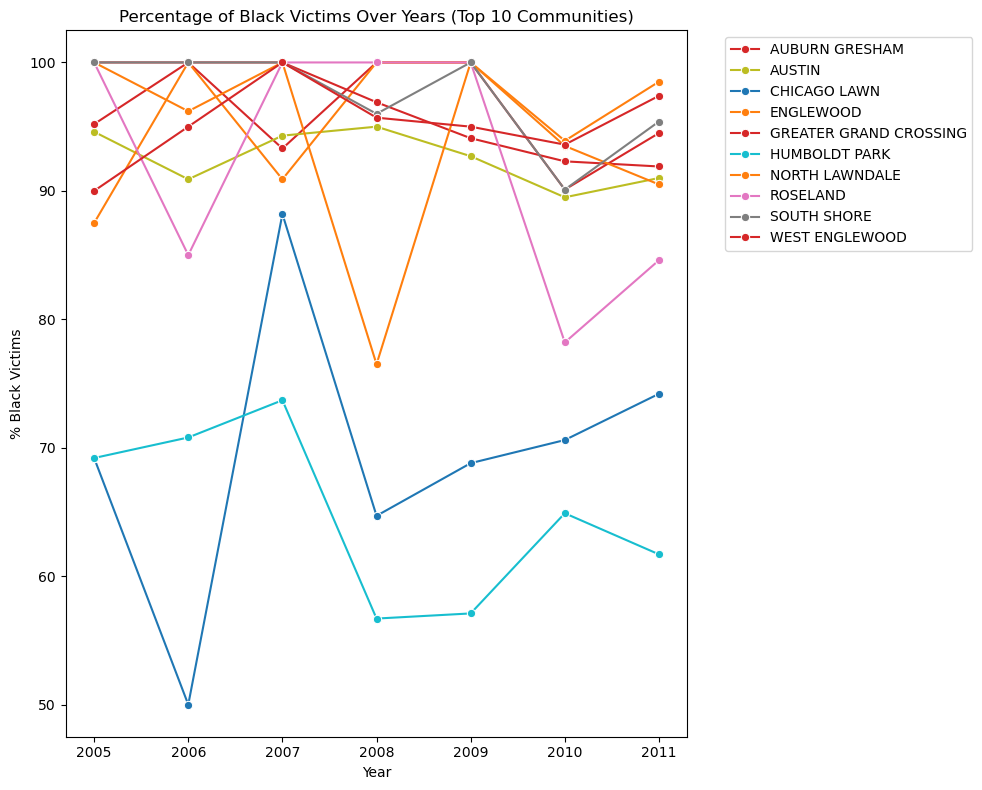

In [179]:
top_areas = demo_summary.groupby('community_area_name')['total_victims'].sum().nlargest(10).index
subset = demo_summary[demo_summary['community_area_name'].isin(top_areas)]

plt.figure(figsize=(10,8))

sns.lineplot(
    data=subset,
    x='year',
    y='blk_pct',
    hue='community_area_name',
    marker='o',
    palette=color_dict 
)

plt.title('Percentage of Black Victims Over Years (Top 10 Communities)')
plt.ylabel('% Black Victims')
plt.xlabel('Year')

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Additional Indicator Exploration

The original notebook began exploring how community indicators relate to violence burden. The final section below continues that idea with a cleaner merged-file analysis and clearer labels.


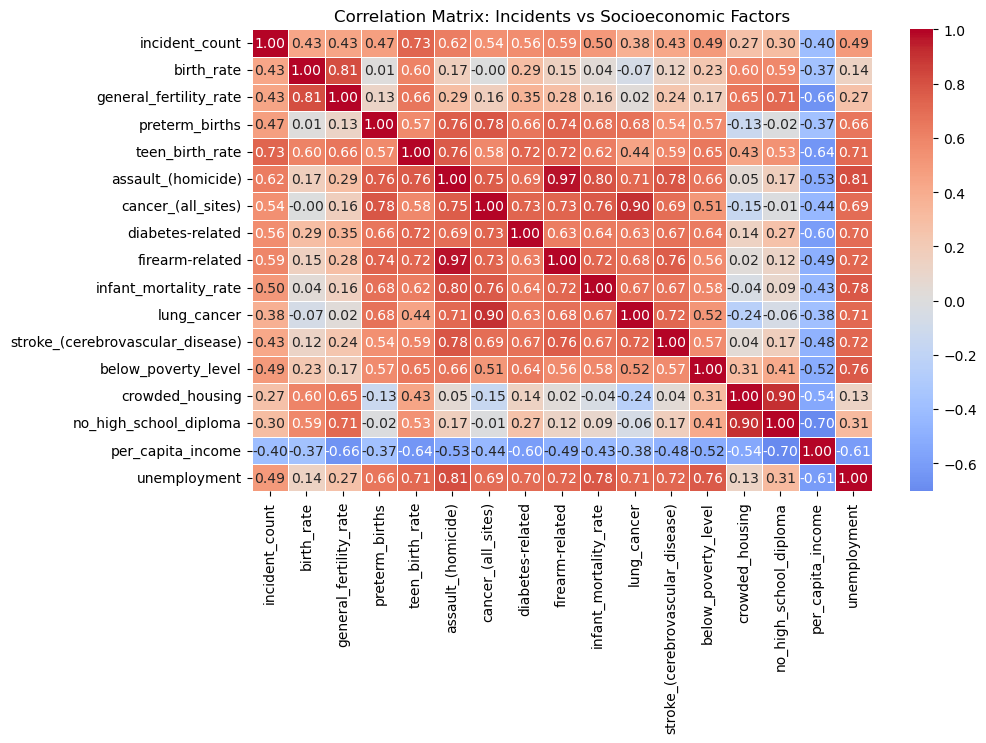

In [ ]:
# Statistics numbers aggregation (can include more!!!!).
area_stats = (df_merged.groupby('community_area_name')
              .agg({'case_number': 'count', "birth_rate": "mean", 
                    "general_fertility_rate": "mean", "preterm_births": "mean", 
                    "teen_birth_rate": "mean", 'assault_(homicide)': 'mean', 
                    "cancer_(all_sites)": "mean", "diabetes-related": "mean", 
                    'firearm-related': 'mean', "infant_mortality_rate": "mean", 
                    "lung_cancer": "mean", "stroke_(cerebrovascular_disease)": "mean", 
                    'below_poverty_level': 'mean', "crowded_housing": "mean", 
                    'no_high_school_diploma': 'mean', 'per_capita_income': 'mean', 
                    'unemployment': 'mean'})
              .rename(columns={'case_number': 'incident_count'})
              .reset_index())

# # Top 15 most dangerous areas
# top15 = area_stats.nlargest(15, 'incident_count')

# plt.figure(figsize=(12, 8))
# sns.barplot(data=top15, x='community_area_name', y='incident_count')
# plt.title('Top 15 Community Areas by Gun Incidents (2005-2011)')
# plt.xlabel('Number of Incidents')
# plt.show()

STAT_COL = area_stats.columns.to_list()
STAT_COL.remove('community_area_name')

# Correlation heatmap.
corr = area_stats[STAT_COL].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Incidents vs Socioeconomic Factors')
plt.show()

In [181]:
# # Relationship between poverty/unemployment and gun violence.
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_merged.groupby('community_area_name').agg({
#     'below_poverty_level': 'mean',
#     'unemployment': 'mean',
#     'firearm-related': 'mean'  # or use incident count
# }).reset_index(), 
# x='below_poverty_level', y='unemployment', 
# size='firearm-related', hue='firearm-related',
# sizes=(20, 200))
# plt.title('Poverty vs Unemployment vs Firearm Incidents by Community Area')
# plt.show()

## Added Community Indicator Analysis

The following section extends the original notebook with a cleaner version of the community-indicator analysis using the team merged file, `merged.csv`. This section keeps the shared `2005-2010` overlap and focuses on the relationship between violence burden and selected socioeconomic indicators.


### Step A: Load the merged file used by the team

This step loads `merged.csv` directly so the final comparison plots are based on the same merged artifact shared by both team members.


In [182]:
from pathlib import Path

merged_filename = "merged.csv"
candidate_dirs = [Path.cwd(), Path.cwd() / "Datasets", Path.cwd().parent]
for candidate in candidate_dirs:
    if (candidate / merged_filename).exists():
        merged_path = candidate / merged_filename
        break
else:
    raise FileNotFoundError("Could not find merged.csv from the current notebook session.")

team_merged = pd.read_csv(merged_path)
team_merged.shape


/var/folders/sl/nkyrzpxx0dl5krcsxt3c69cc0000gn/T/ipykernel_18736/1532942143.py:12: DtypeWarning: Columns (24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  team_merged = pd.read_csv(merged_path)


(63192, 70)

### Step B: Clean the merged data and prepare the shared analysis window

Here we remove direct identifier columns, parse the date field, and keep the shared `2005-2011` period used in the current milestone analysis.


In [183]:
team_working = team_merged.drop(columns=['Unnamed: 0'], errors='ignore').copy()
team_working = team_working.drop(columns=['homicide_victim_first_name', 'homicide_victim_mi', 'homicide_victim_last_name'], errors='ignore')
team_working['date'] = pd.to_datetime(team_working['date'], errors='coerce')
team_working = team_working.dropna(subset=['date', 'year', 'community_area_name']).copy()
team_working['year'] = team_working['year'].astype(int)
team_working = team_working[team_working['year'].between(2005, 2011)].copy()
team_working['gun_violence_victim'] = team_working['gunshot_injury_i'].eq('YES').astype(int)

print('Shared year range:', int(team_working['year'].min()), 'to', int(team_working['year'].max()))
print('Rows used in this section:', len(team_working))


Shared year range: 2005 to 2011
Rows used in this section: 7971


### Step C: Aggregate to community-level averages

Because the health indicators are static at the community level in the merged file, we first compute yearly gun violence totals for each community area and then collapse them into one average annual burden value per community area.


In [ ]:
# Can add more!!!!!
community_year_added = (
    team_working.groupby(['community_area_name', 'year'], as_index=False)
    .agg(
        gun_violence_victims=('gun_violence_victim', 'sum'),
        below_poverty_level=('below_poverty_level', 'first'),
        unemployment=('unemployment', 'first'),
        per_capita_income=('per_capita_income', 'first'),
        no_high_school_diploma=('no_high_school_diploma', 'first'),
        teen_birth_rate=('teen_birth_rate', 'first'),
    )
)

area_level_added = (
    community_year_added.groupby('community_area_name', as_index=False)
    .agg(
        avg_annual_gun_victims=('gun_violence_victims', 'mean'),
        below_poverty_level=('below_poverty_level', 'first'),
        unemployment=('unemployment', 'first'),
        per_capita_income=('per_capita_income', 'first'),
        no_high_school_diploma=('no_high_school_diploma', 'first'),
        teen_birth_rate=('teen_birth_rate', 'first'),
    )
)

area_level_added.head()


,community_area_name,avg_annual_gun_victims,below_poverty_level,unemployment,per_capita_income,no_high_school_diploma,teen_birth_rate
0,ALBANY PARK,5.833333,17.1,9.0,20355,34.9,44.5
1,ARCHER HEIGHTS,2.000000,13.0,14.2,16145,36.4,50.3
2,ARMOUR SQUARE,0.600000,35.8,11.6,16942,37.5,16.2
3,ASHBURN,14.833333,9.5,8.8,22078,18.3,38.3
4,AUBURN GRESHAM,41.000000,24.5,24.2,16022,19.5,83.1


### Step D: Compare three community indicators with average annual violence burden

This figure compares average annual gun violence victims with below-poverty level, unemployment, and per-capita income. The labels are kept explicit so the relationship in each panel is easy to read.


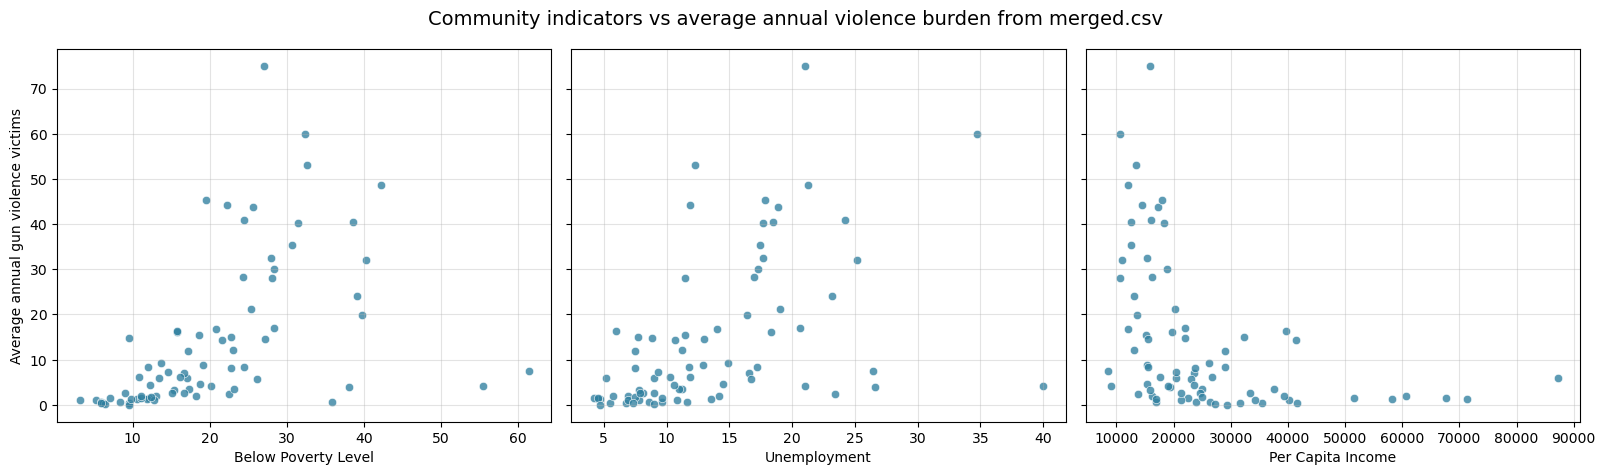

In [185]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

plot_specs = [
    ('below_poverty_level', 'Below Poverty Level'),
    ('unemployment', 'Unemployment'),
    ('per_capita_income', 'Per Capita Income'),
]

for axis, (column, label) in zip(axes, plot_specs):
    axis.scatter(area_level_added[column], area_level_added['avg_annual_gun_victims'], alpha=0.78, color='#2f7f9f', edgecolors='white', linewidth=0.5)
    axis.set_xlabel(label)
    axis.grid(True, alpha=0.35)

axes[0].set_ylabel('Average annual gun violence victims')
fig.suptitle('Community indicators vs average annual violence burden from merged.csv', fontsize=14)
plt.tight_layout()
plt.show()


### Step E: Summarize the correlations used to interpret the plot

This final output reports the correlation strength for the selected indicators so the visual pattern has a matching numeric summary.


In [186]:
correlation_columns_added = [
    'teen_birth_rate',
    'below_poverty_level',
    'unemployment',
    'no_high_school_diploma',
    'per_capita_income',
]

area_level_added[correlation_columns_added + ['avg_annual_gun_victims']].corr()['avg_annual_gun_victims'].drop('avg_annual_gun_victims').sort_values(ascending=False)


teen_birth_rate           0.733745
unemployment              0.497050
below_poverty_level       0.492290
no_high_school_diploma    0.301566
per_capita_income        -0.410328
Name: avg_annual_gun_victims, dtype: float64